In [2]:
import pandas as pd

# baca file CSV
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv', delimiter=";")

df.head(5)




,customerID,gender,Partner,PhoneService,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Churn
0,7590-VHVEG,Female,Yes,No,DSL,No,Yes,No,No,No,No,Yes,No
1,5575-GNVDE,Male,No,Yes,DSL,Yes,No,Yes,No,No,No,No,No
2,3668-QPYBK,Male,No,Yes,DSL,Yes,Yes,No,No,No,No,Yes,Yes
3,7795-CFOCW,Male,No,No,DSL,Yes,No,Yes,Yes,No,No,No,No
4,9237-HQITU,Female,No,Yes,Fiber optic,No,No,No,No,No,No,Yes,Yes


In [12]:
df[['customerID', 'Churn']].sample(5)

,customerID,Churn
521,4109-CYRBD,No
2216,8495-LJDFO,No
3555,6331-EWIEB,Yes
3454,6773-LQTVT,No
2009,7639-OPLNG,No


In [ ]:
df.groupby("InternetService").count() 

,customerID,gender,Partner,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Churn
InternetService,,,,,,,,,,,,
DSL,2045,2045,2045,2045,2045,2045,2045,2045,2045,2045,2045,2045
Fiber optic,2636,2636,2636,2636,2636,2636,2636,2636,2636,2636,2636,2636
No,1318,1318,1318,1318,1318,1318,1318,1318,1318,1318,1318,1318


In [14]:
df = pd.DataFrame(df)
df.head()

,customerID,gender,Partner,PhoneService,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Churn
0,7590-VHVEG,Female,Yes,No,DSL,No,Yes,No,No,No,No,Yes,No
1,5575-GNVDE,Male,No,Yes,DSL,Yes,No,Yes,No,No,No,No,No
2,3668-QPYBK,Male,No,Yes,DSL,Yes,Yes,No,No,No,No,Yes,Yes
3,7795-CFOCW,Male,No,No,DSL,Yes,No,Yes,Yes,No,No,No,No
4,9237-HQITU,Female,No,Yes,Fiber optic,No,No,No,No,No,No,Yes,Yes


In [18]:
#gender
gender = {'Male': 1,'Female': 0}
df.gender = [gender[itemgender] for itemgender in df.gender]

#Partner
Partner = {'Yes': 1,'No': 0}
df.Partner = [Partner[itempartner] for itempartner in df.Partner]

#PhoneService
PhoneService = {'Yes': 1,'No': 0}
df.PhoneService = [PhoneService[itemPhoneService] for itemPhoneService in df.PhoneService]

#InternetService
InternetService = {'Fiber optic': 3,'DSL': 2,'No': 1}
df.InternetService = [InternetService[itemInternetService] for itemInternetService in df.InternetService]

#OnlineSecurity
OnlineSecurity = {'Yes': 3,'No': 2,'No internet service': 1}
df.OnlineSecurity = [OnlineSecurity[itemOnlineSecurity] for itemOnlineSecurity in df.OnlineSecurity]

#OnlineBackup
OnlineBackup = {'Yes': 3,'No': 2,'No internet service': 1}
df.OnlineBackup = [OnlineBackup[itemOnlineBackup] for itemOnlineBackup in df.OnlineBackup]

#DeviceProtection
DeviceProtection = {'Yes': 3,'No': 2,'No internet service': 1}
df.DeviceProtection = [DeviceProtection[itemDeviceProtection] for itemDeviceProtection in df.DeviceProtection]

#TechSupport
TechSupport = {'Yes': 3,'No': 2,'No internet service': 1}
df.TechSupport = [TechSupport[itemTechSupport] for itemTechSupport in df.TechSupport]

#StreamingTV
StreamingTV = {'Yes': 3,'No': 2,'No internet service': 1}
df.StreamingTV = [StreamingTV[itemStreamingTV] for itemStreamingTV in df.StreamingTV]

#StreamingMovies
StreamingMovies = {'Yes': 3,'No': 2,'No internet service': 1}
df.StreamingMovies = [StreamingMovies[itemStreamingMovies] for itemStreamingMovies in df.StreamingMovies]

#PaperlessBilling
PaperlessBilling = {'Yes': 1,'No': 0}
df.PaperlessBilling = [PaperlessBilling[itemPaperlessBilling] for itemPaperlessBilling in df.PaperlessBilling]

#Churn
Churn = {'No': 1,'Yes': 0}
df.Churn = [Churn[itemChurn] for itemChurn in df.Churn]

df.head() #head() → fungsi dari library Pandas untuk menampilkan baris teratas dari dataset.

,customerID,gender,Partner,PhoneService,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Churn
0,7590-VHVEG,0,1,0,2,2,3,2,2,2,2,1,1
1,5575-GNVDE,1,0,1,2,3,2,3,2,2,2,0,1
2,3668-QPYBK,1,0,1,2,3,3,2,2,2,2,1,0
3,7795-CFOCW,1,0,0,2,3,2,3,3,2,2,0,1
4,9237-HQITU,0,0,1,3,2,2,2,2,2,2,1,0


In [19]:
X = df[['gender','Partner','PhoneService','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling']]
y = df['Churn']

In [25]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30) #train_test_split dari scikit-learn Membagi data menjadi: Training (70%) Testing (30%)

from sklearn.linear_model import LogisticRegression #membuat objek modell
logistic_regression= LogisticRegression()
logistic_regression.fit(X_train,y_train) #.fit() → melatih model menggunakan data training
y_pred=logistic_regression.predict(X_test) #Model memprediksi data baru (x_test) Hasil disimpan di y_pred
confusion_matrix = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted']) #pd.crosstab() dari Pandas Membuat tabel perbandingan: Actual (asli) Predicted (hasil model)

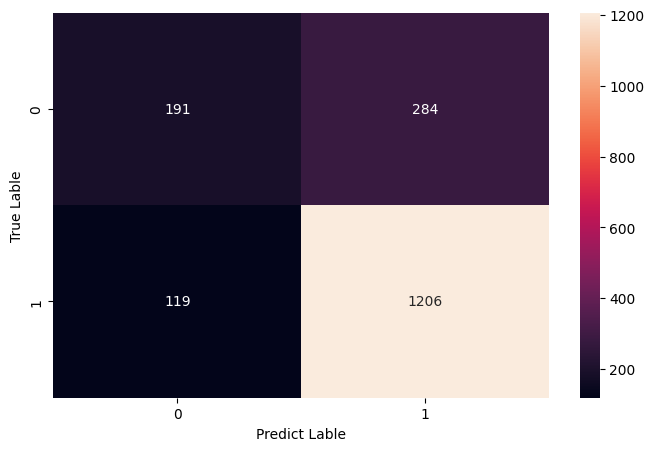

In [28]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred) #seaborn → untuk visualisasi grafik
#confusion_matrix → fungsi evaluasi dari sklearn

import matplotlib.pyplot as plt 
f, ax = plt.subplots(figsize=(8,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt=".0f", ax=ax) #sns.heatmap() → menampilkan confusion matrix dalam bentuk warna annot=True → menampilkan angka di dalam kotak
plt.xlabel("Predict Lable")
plt.ylabel("True Lable")
plt.show()

In [27]:
%pip install seaborn


     ------------------------------------ 294.9/294.9 kB 569.3 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


      customerID  gender  Partner  PhoneService  InternetService  \
0     7590-VHVEG       0        1             0                2   
1     5575-GNVDE       1        0             1                2   
2     3668-QPYBK       1        0             1                2   
3     7795-CFOCW       1        0             0                2   
4     9237-HQITU       0        0             1                3   
...          ...     ...      ...           ...              ...   
5994  9661-ACXBS       0        0             1                3   
5995  2193-SFWQW       1        1             1                3   
5996  5656-JAMLX       1        0             1                1   
5997  3462-BJQQA       0        0             1                3   
5998  0442-TDYUO       1        1             1                1   

      OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  \
0                  2             3                 2            2   
1                  3             2           

Text(0, 0.5, 'Freq')

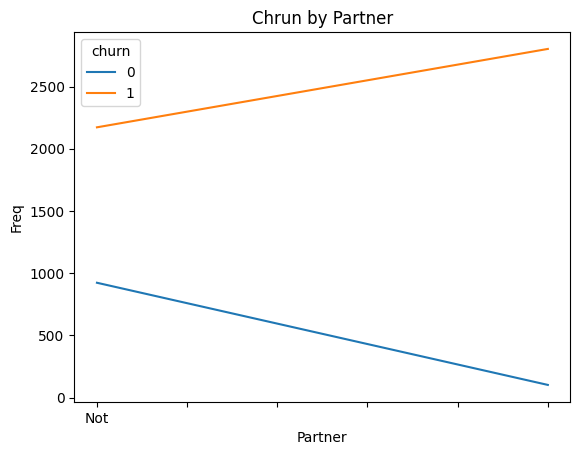

In [31]:
dfT = pd.DataFrame(df)
y_pred=logistic_regression.predict(dfT[['gender','Partner','PhoneService','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling']])
dfT["churn"] = (y_pred)
print(dfT)
dfT["churn"].value_counts() 
PartnerT = {1: 'Partner', 0: "Not"}
dfT.Partner = [PartnerT[itempartnerT] for itempartnerT in dfT.Partner]

pd.crosstab(dfT.Partner,dfT.churn).plot(kind='line') #pd.crosstab() → fungsi dari Pandas Digunakan untuk membuat tabel perbandingan (tabel silang) antara dua variabel #Membuat grafik batang (bar chart) dari tabel tadi
plt.title('Chrun by Partner')
plt.xlabel('Partner')
plt.ylabel('Freq')